## PHYS-467 HW1 Solution

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression, Ridge, Lasso
import sklearn.linear_model as linear_model
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import sklearn.preprocessing as preprocessing

In [2]:
X=pd.read_csv("../Downloads/SUSY.csv",index_col=None,header=None)

In [3]:
X

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999995,1.0,0.853325,-0.961783,-1.487277,0.678190,0.493580,1.647969,1.843867,0.276954,1.025105,-1.486535,0.892879,1.684429,1.674084,3.366298,1.046707,2.646649,1.389226,0.364599
4999996,0.0,0.951581,0.139370,1.436884,0.880440,-0.351948,-0.740852,0.290863,-0.732360,0.001360,0.257738,0.802871,0.545319,0.602730,0.002998,0.748959,0.401166,0.443471,0.239953
4999997,0.0,0.840389,1.419162,-1.218766,1.195631,1.695645,0.663756,0.490888,-0.509186,0.704289,0.045744,0.825015,0.723530,0.778236,0.752942,0.838953,0.614048,1.210595,0.026692
4999998,1.0,1.784218,-0.833565,-0.560091,0.953342,-0.688969,-1.428233,2.660703,-0.861344,2.116892,2.906151,1.232334,0.952444,0.685846,0.000000,0.781874,0.676003,1.197807,0.093689


There are 5000000 data points and 18 features, and the first column corresponds to the labels.

In [7]:
X_tot=X.values[:,1:]
y_tot=np.sign(X.values[:,0]-.5)

In [8]:
X_t, X_test, y_t, y_test = train_test_split(X_tot, y_tot, test_size=0.2)
X_train, X_validation, y_train, y_validation = train_test_split(X_t, y_t, test_size=0.25)

In [9]:
scaler_X = preprocessing.StandardScaler().fit(X_train)
scaler_y = preprocessing.StandardScaler().fit(y_train.reshape(-1,1))

In [10]:
X_test=scaler_X.transform(X_test)
X_train=scaler_X.transform(X_train)
X_validation=scaler_X.transform(X_validation)


We're not using the validation or test set to prevent information of them to "leak" during the training. They should remain unseen data!

In [11]:
def linear_regression(X, y,lamb=0.1):
    """
    arguments:
        - X : data matrix
        - y : output
    returns:
        - w : the least square estimator
    """
    w = np.linalg.inv(X.T.dot(X)+lamb*np.eye(X.shape[1])).dot(X.T).dot(y)
    return w

In [12]:
def accuracy(ypred,ytrue):
    return np.mean(ypred==ytrue)

The sklearn loss is for $y\in\{0,1\}$ and reads
$$
log(1+e^{-X_i w})
$$
if $y_i=1$ and 
$$
log(1+e^{+X_i w})
$$
if $y_i=0$. This corresponds to the expressions in the lecture notes for $y\in\{-1,+1\}$, respectively for $y_i=1$ and $y_i=-1$, so the two expressions are equivalent!

running for regularization 0.1
0.7794263333333333 0.77964
running for regularization 0.35938136638046275
0.7794236666666666 0.779646
running for regularization 1.291549665014884
0.7794276666666666 0.779638
running for regularization 4.641588833612779
0.779426 0.779639
running for regularization 16.68100537200059
0.7794426666666666 0.779636
running for regularization 59.94842503189409
0.779455 0.779658
running for regularization 215.44346900318845
0.779549 0.779765
running for regularization 774.2636826811278
0.779738 0.779824
running for regularization 2782.559402207126
0.779572 0.779516
running for regularization 10000.0
0.7782523333333333 0.778095


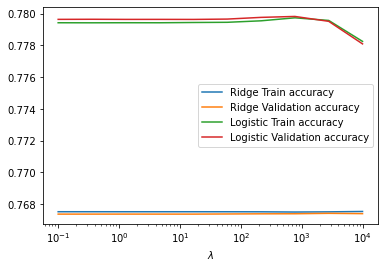

In [13]:


reg_strengths = np.logspace(-1, 4, 10)

ridge_train_acc = []
ridge_val_acc = []
log_train_acc = []
log_val_acc = []

for reg_strength in reg_strengths:
    print("running for regularization",reg_strength)
    # RIDGE CLASSIFICATION
    w=linear_regression(X_train, y_train,lamb=reg_strength)
    y_pred_train=np.sign(X_train@w)
    y_pred_val=np.sign(X_validation@w)
    ridge_train_acc.append(accuracy(y_train, y_pred_train))
    ridge_val_acc.append(accuracy(y_validation, y_pred_val))
    
    # LOGISTIC CLASSIFICATION
    logistic=linear_model.LogisticRegression(fit_intercept=False, C=1/2/reg_strength)
    logistic=logistic.fit(X_train,(1+y_train)/2)
    y_pred_train=np.sign(logistic.predict(X_train)-.5)
    y_pred_val=np.sign(logistic.predict(X_validation)-.5)
    log_train_acc.append(accuracy(y_train, y_pred_train))
    log_val_acc.append(accuracy(y_validation, y_pred_val))
    
    print(accuracy(y_train, y_pred_train),accuracy(y_validation, y_pred_val))

    

plt.plot(reg_strengths, ridge_train_acc, label='Ridge Train accuracy')
plt.plot(reg_strengths, ridge_val_acc, label='Ridge Validation accuracy')
plt.plot(reg_strengths, log_train_acc, label='Logistic Train accuracy')
plt.plot(reg_strengths, log_val_acc, label='Logistic Validation accuracy')
plt.xscale("log")
plt.xlabel('$\lambda$')
plt.legend();

In [15]:
lambda_opt = reg_strengths[np.argmax(log_val_acc)]
print(f'Optimal lambda is {lambda_opt}, the validation error is {np.max(log_val_acc)}')

Optimal lambda is 774.2636826811278, the validation error is 0.779824


We are selecting logistic regression and $\lambda \approx 700$, which yields the highest *validation* accuracy.